In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib import cm

In [52]:
df = pd.read_csv('data/sample_data.csv')
df

,period,CWE-79 (XSS),CWE-89 (SQLi),CWE-22 (Path Traversal),CWE-352 (CSRF),CWE-78 (OS Cmd Inj),CWE-287 (Auth Issues),CWE-200 (Info Leak),CWE-119 (Buffer Overflow),CWE-20 (Input Val),...,CWE-416 (Use After Free),CWE-125 (Out-of-bounds Read),CWE-476 (NULL Deref),CWE-190 (Integer Overflow),CWE-502 (Deserialization),CWE-918 (SSRF),CWE-306 (Missing Auth),CWE-862 (Missing Authz),CWE-77 (Command Inj),CWE-94 (Code Injection)
0,2017-Jan,19,24,9,11,7,15,19,9,7,...,11,8,11,3,1,1,6,10,6,5
1,2017-Mar,26,26,8,16,8,17,17,19,14,...,14,5,11,5,4,3,12,4,8,4
2,2017-May,29,16,16,6,6,17,16,17,10,...,9,3,6,5,12,5,10,9,3,6
3,2017-Jul,32,18,8,9,9,10,24,11,9,...,10,15,6,8,3,8,6,9,11,8
4,2017-Sep,25,22,12,14,11,10,24,9,13,...,11,2,7,4,5,3,3,5,8,9
5,2017-Nov,29,14,15,10,8,17,24,19,10,...,12,13,9,5,4,5,11,5,12,5
6,2018-Jan,26,21,8,15,7,14,21,12,7,...,8,4,9,3,11,3,10,6,4,5
7,2018-Mar,21,17,12,10,9,18,21,20,14,...,11,8,9,2,6,5,5,4,11,11
8,2018-May,20,29,13,8,4,11,18,14,8,...,12,13,3,6,9,4,3,5,7,5
9,2018-Jul,21,22,13,14,11,20,16,12,9,...,12,11,8,8,9,6,8,8,12,9


In [53]:
periods = df['period'].values
cve_columns = [c for c in df.columns if c != 'period']
cve_short = [c.split(' ')[0] for c in cve_columns]
n_cves = len(cve_columns)
n_periods = len(periods)

# Build the occurrence matrix — one row per CWE, columns are time periods
data = df[cve_columns].values.astype(float).T  # (n_cves x n_periods)

# Smooth each CWE's time series with interpolation for wave appearance
interp_factor = 8
x_raw = np.arange(n_periods)
x_fine = np.linspace(0, n_periods - 1, (n_periods - 1) * interp_factor + 1)

data_smooth = np.zeros((n_cves, len(x_fine)))
for i in range(n_cves):
    data_smooth[i] = np.interp(x_fine, x_raw, data[i])

print(f'{n_cves} CVE categories, {n_periods} bi-monthly periods, max occurrence = {int(data.max())}')

20 CVE categories, 48 bi-monthly periods, max occurrence = 32


C:\Users\orcac\AppData\Local\Temp\ipykernel_26992\3794753096.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cool', n_cves)
C:\Users\orcac\AppData\Local\Temp\ipykernel_26992\3794753096.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


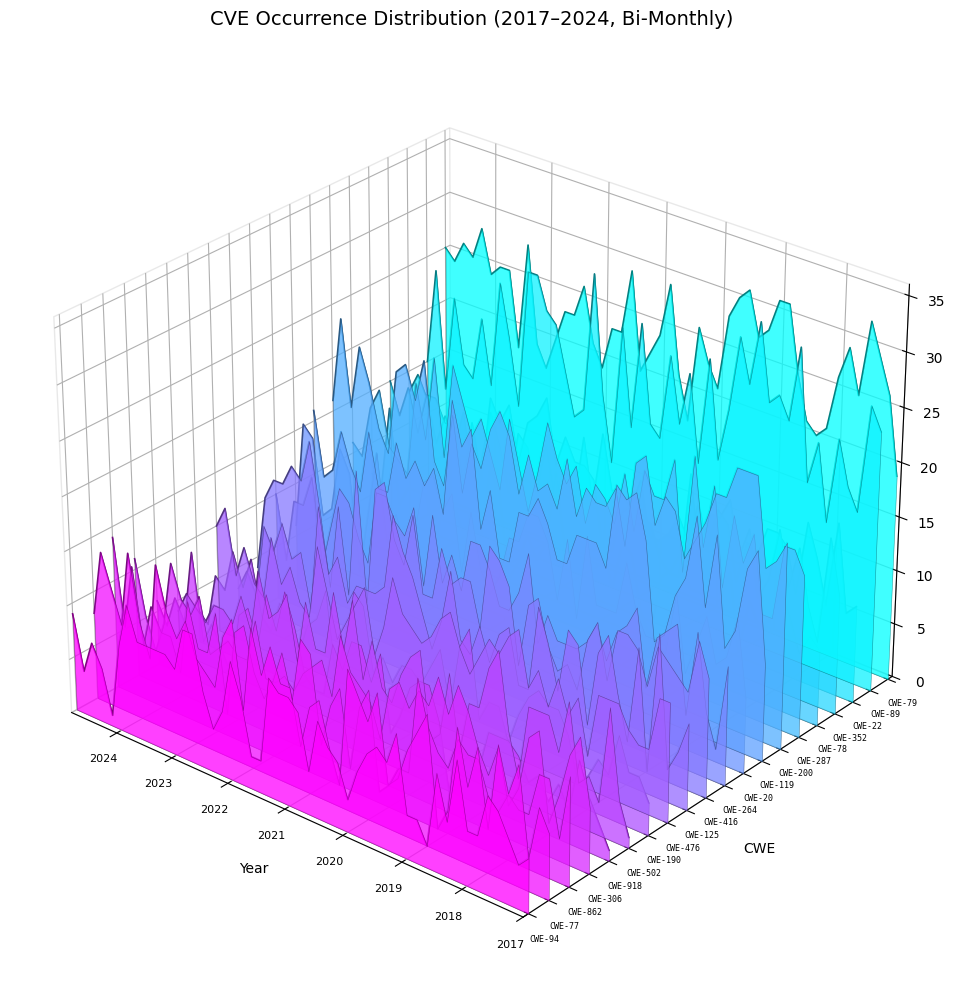

In [54]:
fig = plt.figure(figsize=(20, 12))
ax = fig.add_subplot(111, projection='3d')

# Color map — one color per CWE
cmap = cm.get_cmap('cool', n_cves)

# Axes layout:  X = Time periods,  Y = CWE (depth, one ridge per CWE),  Z = Occurrences
y_spacing = 4  # generous spacing so CWE labels don't overlap

# Render back-to-front so front CWEs occlude rear ones cleanly
render_order = list(range(n_cves))[::-1]

for idx in render_order:
    y_val = idx * y_spacing
    z_vals = data_smooth[idx]          # occurrences on Z

    # Build a filled polygon in the X-Z plane at depth y_val
    verts = []
    verts.append((x_fine[0], y_val, 0))
    for j in range(len(x_fine)):
        verts.append((x_fine[j], y_val, z_vals[j]))
    verts.append((x_fine[-1], y_val, 0))

    color = cmap(idx / max(n_cves - 1, 1))

    # Darker edge: scale RGB down by 50%
    dark = (color[0] * 0.5, color[1] * 0.5, color[2] * 0.5, 1.0)

    # Filled face with dark edge
    poly = Poly3DCollection([verts], alpha=0.75, zorder=-idx)
    poly.set_facecolor((*color[:3], 0.6))
    poly.set_edgecolor(dark)
    poly.set_linewidth(0.4)
    ax.add_collection3d(poly)

    # Ridge line on top — darker color for definition
    ax.plot(x_fine, [y_val] * len(x_fine), z_vals,
            color=dark, linewidth=1.2, zorder=-idx + 1)

# --- X axis: Time periods — label every Jan ---
x_ticks = []
x_labels = []
for i, p in enumerate(periods):
    if p.endswith('-Jan'):
        x_ticks.append(i)
        x_labels.append(p.split('-')[0])
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=8)
ax.set_xlabel('Year', fontsize=10, labelpad=10)
ax.set_xlim(n_periods - 1, 0)

# --- Y axis: CWE categories (depth, one ridge each) ---
ax.set_yticks([i * y_spacing for i in range(n_cves)])
ax.set_yticklabels(cve_short, fontsize=6, family='monospace')
ax.set_ylabel('CWE', fontsize=10, labelpad=12)
ax.set_ylim((n_cves - 1) * y_spacing + 1, -1)

# --- Z axis: Occurrences (height) ---
ax.set_zlim(0, int(data.max() * 1.15))
ax.set_zlabel('Occurrences', fontsize=10, labelpad=10)

# Viewing angle
ax.view_init(elev=28, azim=-50)

# Clean up pane backgrounds
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('lightgray')
ax.yaxis.pane.set_edgecolor('lightgray')
ax.zaxis.pane.set_edgecolor('lightgray')
ax.grid(True, alpha=0.3)

ax.set_title('CVE Occurrence Distribution (2017\u20132024, Bi-Monthly)', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

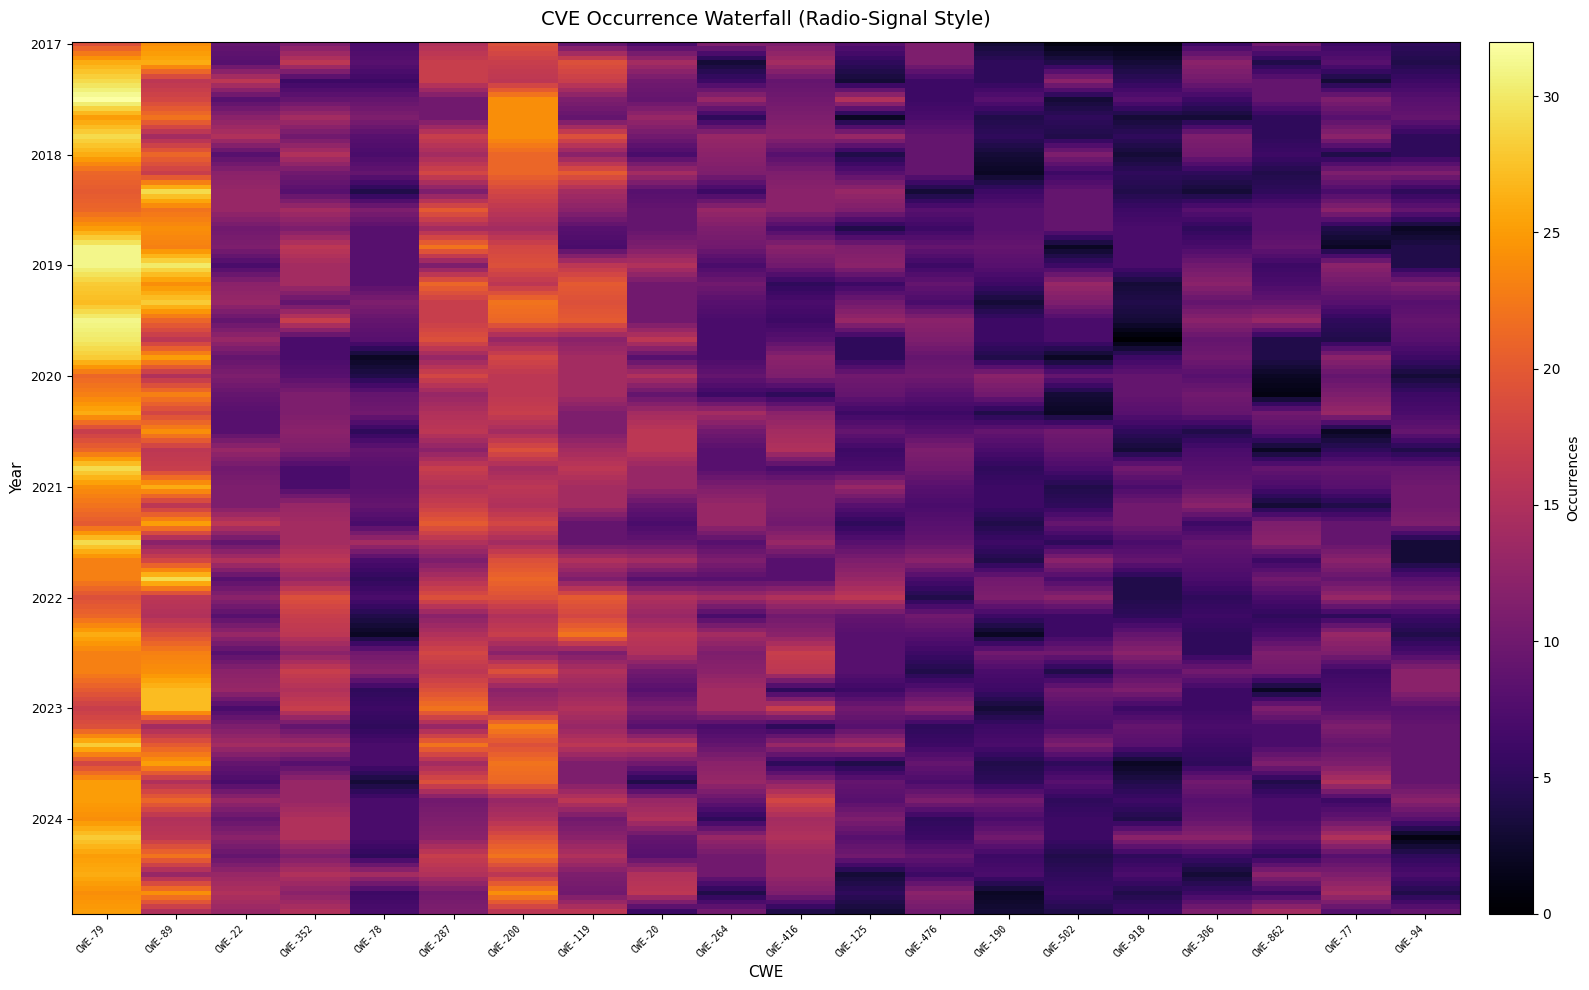

In [55]:
# --- Radio-signal style waterfall: 2-D heatmap ---
# X = CWE categories (columns), Y = time falling downward, color = occurrence intensity

# Use original (non-transposed) data: rows=periods, cols=CWEs
heatmap_data = df[cve_columns].values.astype(float)

# Upsample time axis (rows) only — no interpolation between CWE columns
upsample = 4
n_rows_smooth = (n_periods - 1) * upsample + 1
heatmap_smooth = np.zeros((n_rows_smooth, n_cves))
rows_orig = np.arange(n_periods)
rows_fine = np.linspace(0, n_periods - 1, n_rows_smooth)
for col in range(n_cves):
    heatmap_smooth[:, col] = np.interp(rows_fine, rows_orig, heatmap_data[:, col])

fig, ax = plt.subplots(figsize=(16, 10))

# Use pcolormesh instead of imshow to avoid bilinear blending between columns
# Each CWE gets its own sharp vertical stripe
x_edges = np.arange(n_cves + 1) - 0.5
y_edges = np.linspace(-0.5, n_rows_smooth - 0.5, n_rows_smooth + 1)

im = ax.pcolormesh(
    x_edges, y_edges, heatmap_smooth,
    cmap='inferno',
    shading='flat',
)
ax.set_ylim(n_rows_smooth - 0.5, -0.5)  # time flows downward
ax.set_xlim(-0.5, n_cves - 0.5)

# --- X axis: CWE categories ---
ax.set_xticks(np.arange(n_cves))
ax.set_xticklabels(cve_short, fontsize=7, rotation=45, ha='right', family='monospace')
ax.set_xlabel('CWE', fontsize=11)

# --- Y axis: Time falling down — label every Jan ---
y_ticks_orig = []
y_labels_list = []
for i, p in enumerate(periods):
    if p.endswith('-Jan'):
        y_ticks_orig.append(i)
        y_labels_list.append(p.split('-')[0])

y_ticks_smooth = [int(t * upsample) for t in y_ticks_orig]
ax.set_yticks(y_ticks_smooth)
ax.set_yticklabels(y_labels_list, fontsize=9)
ax.set_ylabel('Year', fontsize=11)

# Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label('Occurrences', fontsize=10)

ax.set_title('CVE Occurrence Waterfall (Radio-Signal Style)', fontsize=14, pad=12)

plt.tight_layout()
plt.show()